In [ ]:
import os
import re
from pathlib import Path

from aind_dynamic_foraging_behavior_video_analysis.kinematics.video_clip_utils import (
    extract_clips_ffmpeg_after_reencode,
)

SESSION_DIR_PATTERN = re.compile(
    r"^behavior_\d+_\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2}$"
)

def find_behavior_sessions(base_dir):
    base_path = Path(base_dir)
    return sorted(
        [p for p in base_path.iterdir() if p.is_dir() and SESSION_DIR_PATTERN.match(p.name)],
        key=lambda p: p.name
    )


def extract_one_second_clips(
    data_dir="/root/capsule/data",
    scratch_dir="/root/capsule/scratch",
    timestamps=(0.0,),
    clip_length=1.0,
    camera_subpath=("behavior-videos", "SideCameraRight", "video.mp4"),
    camera_name="SideCameraRight",
):
    sessions = find_behavior_sessions(data_dir)
    print(f"Found {len(sessions)} sessions in {data_dir}")

    # Output camera dir once (no per-session nesting)
    output_camera_dir = Path(scratch_dir) / "Clips" / camera_name
    output_camera_dir.mkdir(parents=True, exist_ok=True)

    for session in sessions:
        video_path = session.joinpath(*camera_subpath)
        if not video_path.is_file():
            print(f"Skipping {session.name}: missing video")
            continue

        # Filename stems include the session name
        filename_stems = [
            f"{session.name}_clip{i+1}" for i in range(len(timestamps))
        ]

        print(f"[{session.name}] -> {output_camera_dir}")
        extract_clips_ffmpeg_after_reencode(
            input_video_path=str(video_path),
            timestamps=list(timestamps),
            clip_length=float(clip_length),
            output_dir=str(output_camera_dir),
            filename_stems=filename_stems,
        )


if __name__ == "__main__":
    extract_one_second_clips()


In [1]:
from pathlib import Path

from aind_dynamic_foraging_behavior_video_analysis.kinematics.video_clip_utils import (
    extract_clips_ffmpeg_after_reencode,
)

# --- inputs ---
VIDEOS = [
    "/root/capsule/data/behavior_716325_2024-05-31_10-31-14/behavior-videos/BottomCamera/video.mp4",
    "/root/capsule/data/behavior_716325_2024-05-31_10-31-14_videoprocessed_2025-10-28_23-21-23/pred_outputs/video_preds/labeled_videos/video_labeled.mp4",
]

OUT_DIR = Path("/root/capsule/scratch/videoexamples") 
CLIP_START_S = 0.0
CLIP_LEN_S = 5 * 60  # 5 minutes


def extract_five_minute_from_start(videos, out_dir, start_s=0.0, clip_len_s=300.0):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    for v in videos:
        in_path = Path(v)
        if not in_path.is_file():
            print(f"Missing: {in_path}")
            continue

        # make a reasonable, unique stem
        # e.g. "behavior_...__BottomCamera__video_5min_from_start"
        parts = list(in_path.parts)
        camera = "unknown_camera"
        if "behavior-videos" in parts:
            i = parts.index("behavior-videos")
            if i + 1 < len(parts):
                camera = parts[i + 1]
        elif "labeled_videos" in parts:
            camera = "labeled"

        sessionish = next((p for p in parts if p.startswith("behavior_")), "video")
        stem = f"{sessionish}__{camera}__{in_path.stem}_5min_from_start"

        print(f"Extracting -> {out_dir / (stem + '.mp4')}")
        extract_clips_ffmpeg_after_reencode(
            input_video_path=str(in_path),
            timestamps=[float(start_s)],
            clip_length=float(clip_len_s),
            output_dir=str(out_dir),
            filename_stems=[stem],
        )


if __name__ == "__main__":
    extract_five_minute_from_start(VIDEOS, OUT_DIR, start_s=CLIP_START_S, clip_len_s=CLIP_LEN_S)

Extracting -> /root/capsule/scratch/videoexamples/behavior_716325_2024-05-31_10-31-14__BottomCamera__video_5min_from_start.mp4


ffmpeg version 4.2.7-0ubuntu0.1 Copyright (c) 2000-2022 the FFmpeg developers
  built with gcc 9 (Ubuntu 9.4.0-1ubuntu1~20.04.1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-avresample --disable-filter=resample --enable-avisynth --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librsvg --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --e

Clip saved to /root/capsule/scratch/videoexamples/behavior_716325_2024-05-31_10-31-14__BottomCamera__video_5min_from_start_0.000s_to_300.000s.mp4
Extracting -> /root/capsule/scratch/videoexamples/behavior_716325_2024-05-31_10-31-14_videoprocessed_2025-10-28_23-21-23__labeled__video_labeled_5min_from_start.mp4


ffmpeg version 4.2.7-0ubuntu0.1 Copyright (c) 2000-2022 the FFmpeg developers
  built with gcc 9 (Ubuntu 9.4.0-1ubuntu1~20.04.1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-avresample --disable-filter=resample --enable-avisynth --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librsvg --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --e

Clip saved to /root/capsule/scratch/videoexamples/behavior_716325_2024-05-31_10-31-14_videoprocessed_2025-10-28_23-21-23__labeled__video_labeled_5min_from_start_0.000s_to_300.000s.mp4


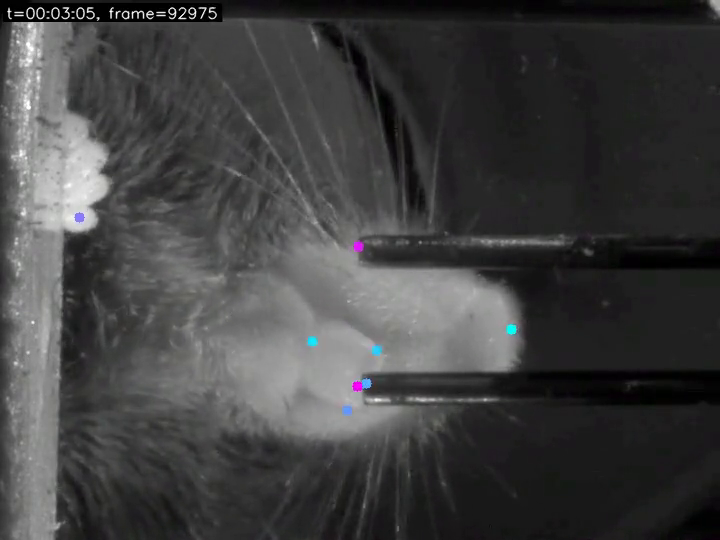

Saved: /root/capsule/scratch/videoexamples/behavior_716325_2024-05-31_10-31-14_videoprocessed_2025-10-28_23-21-23__labeled__video_labeled_5min_from_start_0.000s_to_300.000s__frame_185.950s.png


In [4]:
from pathlib import Path
import subprocess
from IPython.display import Image, display

VIDEO = Path("/root/capsule/scratch/videoexamples/behavior_716325_2024-05-31_10-31-14_videoprocessed_2025-10-28_23-21-23__labeled__video_labeled_5min_from_start_0.000s_to_300.000s.mp4")

# --- choose the timestamp (seconds from start) ---
t = 185.95  # <- change me (e.g., 0.0, 10.0, 123.456)

# output path
out_png = VIDEO.with_suffix("")  # strip .mp4
out_png = out_png.with_name(out_png.name + f"__frame_{t:0.3f}s.png")

# Extract 1 frame.
# -ss before -i = fast seek (usually good enough). If you need exact frame accuracy, see note below.
cmd = [
    "ffmpeg",
    "-hide_banner", "-loglevel", "error",
    "-ss", f"{t}",
    "-i", str(VIDEO),
    "-frames:v", "1",
    "-q:v", "2",
    "-y",
    str(out_png),
]

subprocess.run(cmd, check=True)

display(Image(filename=str(out_png)))
print("Saved:", out_png)